In [13]:
import pandas as pd 
import numpy as np

In [33]:
df_pop = pd.read_csv("../Extacted data/Population/Spain_population_by_city.csv")
df_weather = pd.read_csv('./data/all_weather_clean.csv')
df_pop_total =pd.read_csv('./data/All_population_yearly.csv')

In [10]:
df_pop

,Unnamed: 0,2025,2024,2023,2022,2021
0,Bilbao,351124,348089,346096,344127,346405
1,Santiago de Compostela,100965,99536,98687,98179,97858
2,Barcelona,1731649,1702547,1660122,1636193,1636732
3,Zaragoza,693091,686986,682513,67301,675301
4,Seville,689423,687488,684025,681998,684234
5,Malaga,1791092,1773136,1751600,1717504,1695651
6,Madrid,3506730,3416771,3332035,3280782,3305408
7,Valencia,840792,825948,807693,792492,789744


In [11]:
df_pop = df_pop.rename(columns={'Unnamed: 0': 'City'})

In [12]:
df_pop_long = df_pop.melt(
    id_vars='City',
    var_name='Year',
    value_name='Population'
)

df_pop_long['Year'] = df_pop_long['Year'].astype(int)

In [14]:
def expand_to_monthly_city(df_pop):

    monthly_records = []

    for city in df_pop['City'].unique():

        df_city = (
            df_pop[df_pop['City'] == city]
            .sort_values('Year')
            .reset_index(drop=True)
        )

        # average annual growth
        populations = df_city['Population'].values

        annual_growth_rates = [
            (populations[i+1] - populations[i]) / populations[i]
            for i in range(len(populations)-1)
        ]

        avg_growth_rate = np.mean(annual_growth_rates)

        # interpolate 2021-2024
        for i in range(len(df_city)-1):

            year_start = df_city.loc[i, 'Year']
            pop_start = df_city.loc[i, 'Population']
            pop_end = df_city.loc[i+1, 'Population']

            for month in range(1, 13):

                fraction = (month-1)/12

                population = (
                    pop_start +
                    (pop_end-pop_start)*fraction
                )

                monthly_records.append({
                    'date': f'{year_start}-{month:02d}',
                    'city': city,
                    'population': round(population)
                })

        # generate full 2025 using growth rate
        last = df_city.iloc[-1]

        last_year = last['Year']
        last_pop = last['Population']

        projected_next_pop = last_pop * (1 + avg_growth_rate)

        for month in range(1, 13):

            fraction = (month-1)/12

            population = (
                last_pop +
                (projected_next_pop-last_pop)*fraction
            )

            monthly_records.append({
                'date': f'{last_year}-{month:02d}',
                'city': city,
                'population': round(population)
            })

    return pd.DataFrame(monthly_records)

In [29]:
df_monthly_pop = expand_to_monthly_city(df_pop_long)
df_monthly_pop.tail()

,date,city,population
475,2025-08,Valencia,848546
476,2025-09,Valencia,849653
477,2025-10,Valencia,850761
478,2025-11,Valencia,851868
479,2025-12,Valencia,852976


In [30]:
df_monthly_pop.to_csv("Spain_population_per_city.csv", index=False)

In [18]:
df_monthly_pop['date'] = pd.to_datetime(df_monthly_pop['date'])
df_weather['date'] = pd.to_datetime(df_weather['date'])

In [19]:
df_weather_pop = df_weather.merge(
    df_monthly_pop,
    left_on=['station_name', 'date'],
    right_on=['city', 'date'],
    how='left'
)

In [20]:
weighted_weather = (
    df_weather_pop
    .groupby('date')
    .apply(
        lambda x: pd.Series({
            'prcp_weighted':
                (x['prcp'] * x['population']).sum()
                / x['population'].sum(),

            'tsun_weighted':
                (x['tsun'] * x['population']).sum()
                / x['population'].sum()
        })
    )
    .reset_index()
)

In [21]:
weighted_weather

,date,prcp_weighted,tsun_weighted
0,2021-01-01,73.867411,9277.855404
1,2021-02-01,34.535826,8340.437258
2,2021-03-01,15.749954,13200.223909
3,2021-04-01,57.807247,10749.495619
4,2021-05-01,28.440731,16908.012429
5,2021-06-01,17.056963,17588.073561
6,2021-07-01,4.146141,21168.637420
7,2021-08-01,15.683461,18216.476360
8,2021-09-01,48.319072,13355.862708
9,2021-10-01,44.523457,13998.020182


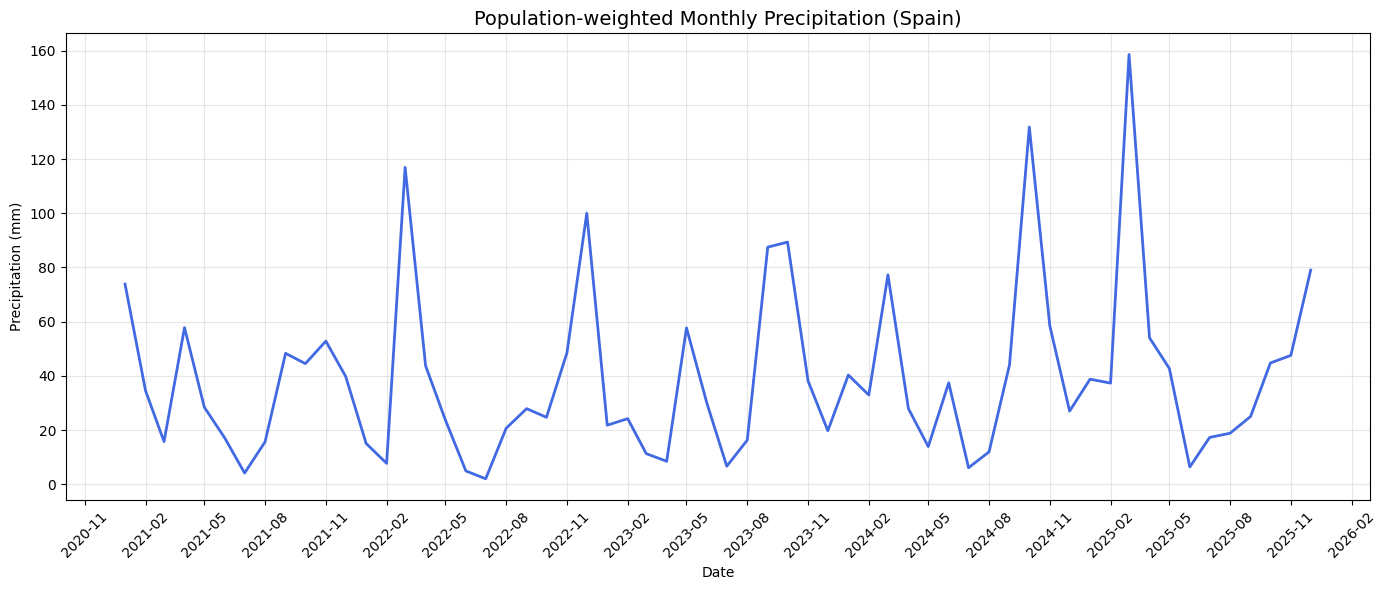

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(
    weighted_weather['date'],
    weighted_weather['prcp_weighted'],
    linewidth=2,
    color='royalblue'
)

ax.set_title(
    'Population-weighted Monthly Precipitation (Spain)',
    fontsize=14
)

ax.set_ylabel('Precipitation (mm)')
ax.set_xlabel('Date')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

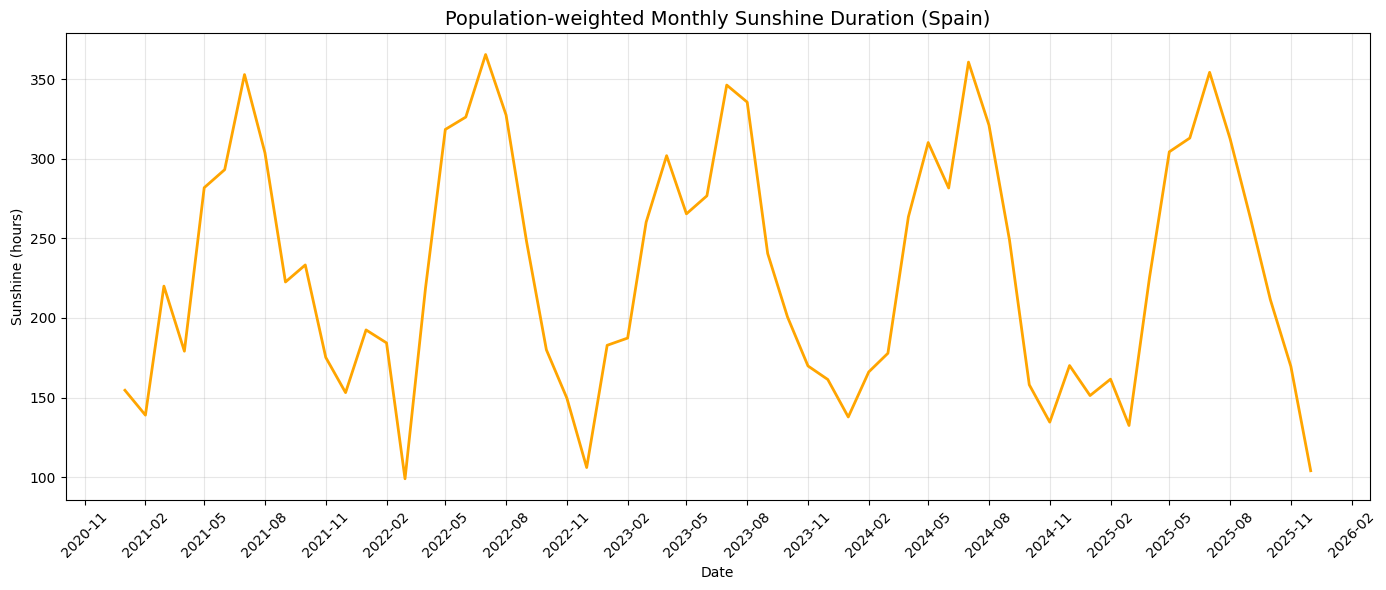

In [24]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(
    weighted_weather['date'],
    weighted_weather['tsun_weighted']/60,  # convert to hours
    linewidth=2,
    color='orange'
)

ax.set_title(
    'Population-weighted Monthly Sunshine Duration (Spain)',
    fontsize=14
)

ax.set_ylabel('Sunshine (hours)')
ax.set_xlabel('Date')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
weighted_stats = (
    df_weather_pop
    .groupby('date')
    .agg(
        prcp_mean=('prcp', 'mean'),
        prcp_std=('prcp', 'std')
    )
    .reset_index()
)

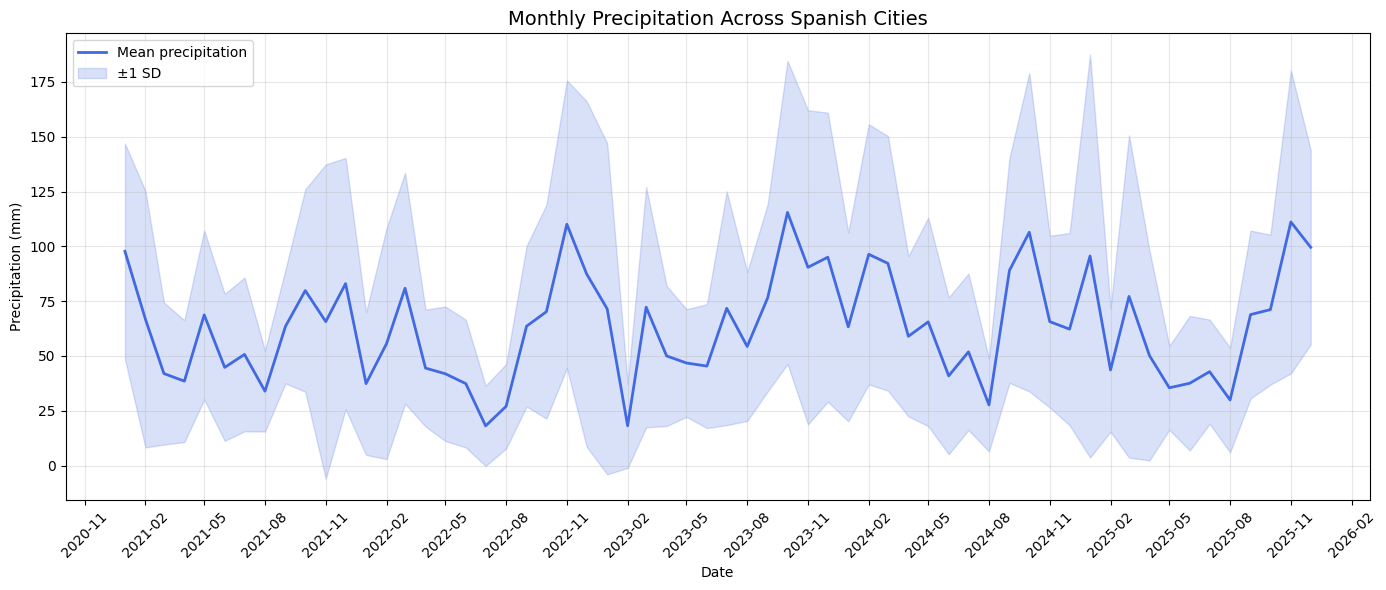

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14,6))

# Mean line
ax.plot(
    weighted_stats['date'],
    weighted_stats['prcp_mean'],
    linewidth=2,
    color='royalblue',
    label='Mean precipitation'
)

# Std band
ax.fill_between(
    weighted_stats['date'],
    weighted_stats['prcp_mean'] - weighted_stats['prcp_std'],
    weighted_stats['prcp_mean'] + weighted_stats['prcp_std'],
    color='royalblue',
    alpha=0.2,
    label='±1 SD'
)

ax.set_title(
    'Monthly Precipitation Across Spanish Cities',
    fontsize=14
)

ax.set_ylabel('Precipitation (mm)')
ax.set_xlabel('Date')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
def weighted_avg(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return None
    return (values[mask] * weights[mask]).sum() / weights[mask].sum()

In [34]:
# Step 1: Merge weather with Spain city population
spain_cities = ['Bilbao', 'Santiago de Compostela', 'Valencia', 'Barcelona', 
                'Seville', 'Malaga', 'Madrid', 'Zaragoza']

df_w_spain = df_weather[df_weather['station_name'].isin(spain_cities)].copy()

# Merge with city population
df_w_spain = df_w_spain.merge(df_pop, 
                               left_on=['date', 'station_name'], 
                               right_on=['date', 'city'], 
                               how='left')

# Merge with total Spain population
df_w_spain = df_w_spain.merge(df_pop_total[['date', 'population']], 
                               on='date', 
                               how='left',
                               suffixes=('_city', '_total'))

# Step 2: Calculate weight
df_w_spain['weight'] = df_w_spain['population_city'] / df_w_spain['population_total']

# Step 3: Calculate weighted values
df_w_spain['tavg_w'] = df_w_spain['tavg'] * df_w_spain['weight']
df_w_spain['prcp_w'] = df_w_spain['prcp'] * df_w_spain['weight']
df_w_spain['tsun_w'] = df_w_spain['tsun'] * df_w_spain['weight']

# Step 4: Group by date and sum weighted values
df_spain_weighted = df_w_spain.groupby('date').agg(
    tavg=('tavg_w', 'sum'),
    prcp=('prcp_w', 'sum'),
    tsun=('tsun_w', 'sum')
).round(1).reset_index()

df_spain_weighted['country'] = 'Spain'

print(df_spain_weighted.head(10))

KeyError: 'date'